In [1]:
import pandas as pd
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
from WMSE import WMSE, WMSE_metric

import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="0"
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()


2025-04-25 10:59:45.702055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745575185.714046 1346161 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745575185.717536 1346161 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)
jax.process_index(backend=None)

/tmp/ipykernel_1346161/4047632791.py:2: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


cpu


0

In [4]:
seed = 42

df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnuSer'] = np.log10(df_full['dnuSer']*135)

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnuSer'] 

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())
df_train = df.sample(frac=0.95, random_state=seed)
df_test = df.drop(df_train.index)
df_small = df_full.sample(1000)

In [5]:
normconsts = np.load('../grids/Chiara-normconsts-logAge.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 6

dense_layer_units = 128

Nepochs = 5000

learning_rate = 0.0001

model_name = 'logAge-logLPhot-lognumax-logdnuSer-exponent-6e-6-Adam'

loss_func = 'WMSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':model_name, 'n_dense_layers':n_dense_layers, 'dense_layer_units':dense_layer_units, 'Nepochs':Nepochs, 'lrate':learning_rate, \
        'loss':loss_func, 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'lognumax', 'logdnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir, 'custom_objects':{'WMSE':WMSE_metric}}

model_outputs = Emulator(emulator_kwargs, normalised = False)
model= tf.keras.models.load_model(checkpoint_dir, custom_objects = {'WMSE':WMSE_metric})

I0000 00:00:1745575209.166908 1346161 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1157 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


In [209]:
H22 = pd.read_csv('../data/Howell_2022.txt')
H22 = H22[(H22['QF'] == 'D')&(H22['ID'].str.contains('RGB'))].reset_index()[0:10]

numax = H22['νmax'].str.split('±', expand=True)[0].astype(float)
enumax = H22['νmax'].str.split('±', expand=True)[1].astype(float)

dnu = H22['∆ν'].str.split('±', expand=True)[0].astype(float)
ednu = H22['∆ν'].str.split('±', expand=True)[1].astype(float)

LPhot = H22['L/L⊙'].str.split('±', expand=True)[0].astype(float)
eLPhot = 0.5*np.sqrt(H22['L/L⊙'].str.split('±', expand=True)[1].astype(float)**2 + H22['L/L⊙'].str.split('±', expand=True)[2].astype(float)**2)


Teff = H22['Teff'].str.split('±', expand=True)[0].astype(float)
eTeff = H22['Teff'].str.split('±', expand=True)[1].astype(float)

num_stars = len(Teff)

obs = {'FeH':-1.1*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values)}
unc = {'Teff':eTeff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.07*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10)}

# Fit a fake cluster - hierarchical on age

In [244]:
def shared_2param(uncs,  obs = model_outputs.obs_dict):

    mu_age = sample_beta('mu_age', 10000, 5000, alpha = 2, beta = 2)

    std_age = sample_beta('std_age', 100, 2000, alpha = 2, beta = 2)


    with numpyro.plate("star", num_stars):    

        age = numpyro.sample('age', dist.TruncatedNormal(mu_age, std_age, low = 0))

        tau = sample_beta('tau', 1, 0.1, alpha = 2, beta = 2)

        massini = numpyro.deterministic ('massini', tau*(0.6426*10**4/age)**(1/3.2))

        zini = numpyro.sample('zini', dist.TruncatedNormal(1.5*0.01756*10**-1.1, 0.7*0.01756*10**-1.1, low = 0))

        yini = numpyro.sample('yini', dist.TruncatedNormal(0.245, 0.03, low = 0.22))

        alphaMLT = numpyro.sample('alphaMLT', dist.TruncatedNormal(1.9,0.1, low = 1.5, high = 2.3))

        eta = numpyro.sample('eta', dist.TruncatedNormal(0.1, 0.1, low = 0, high = 0.3))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(0.4, 0.05))
               
        params = jnp.stack([massini, zini, yini, alphaMLT, jnp.log10(age), eta, alphaFe], axis = -1)

        pred = model_outputs(params)

    FeH = numpyro.sample("FeH", dist.Normal(pred[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    logLPhot = numpyro.sample("logLPhot", dist.Normal(pred[:, 1], uncs['logLPhot']), obs=obs['logLPhot'])
    
    Teff = numpyro.sample("Teff", dist.Normal(pred[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(10**(pred[:, 3]), uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(10**(pred[:, 4]), uncs['dnuSer']), obs=obs['dnuSer'])
 





In [245]:
num_warmup, num_samples = 4000, 4000

num_chains = 1

sampler = NUTS(shared_2param, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [246]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(shared_2param, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

(array([ 32.,  81., 111., 135., 136., 134., 157.,  94.,  78.,  42.]),
 array([10014.04622825, 10508.78583833, 11003.52544842, 11498.2650585 ,
        11993.00466858, 12487.74427867, 12982.48388875, 13477.22349884,
        13971.96310892, 14466.702719  , 14961.44232909]),
 <BarContainer object of 10 artists>)

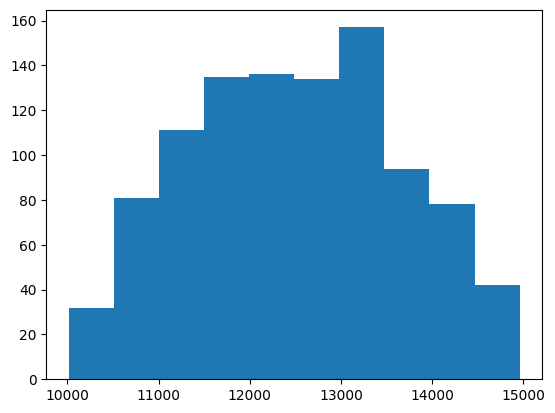

In [247]:
plt.hist(prior['mu_age'])

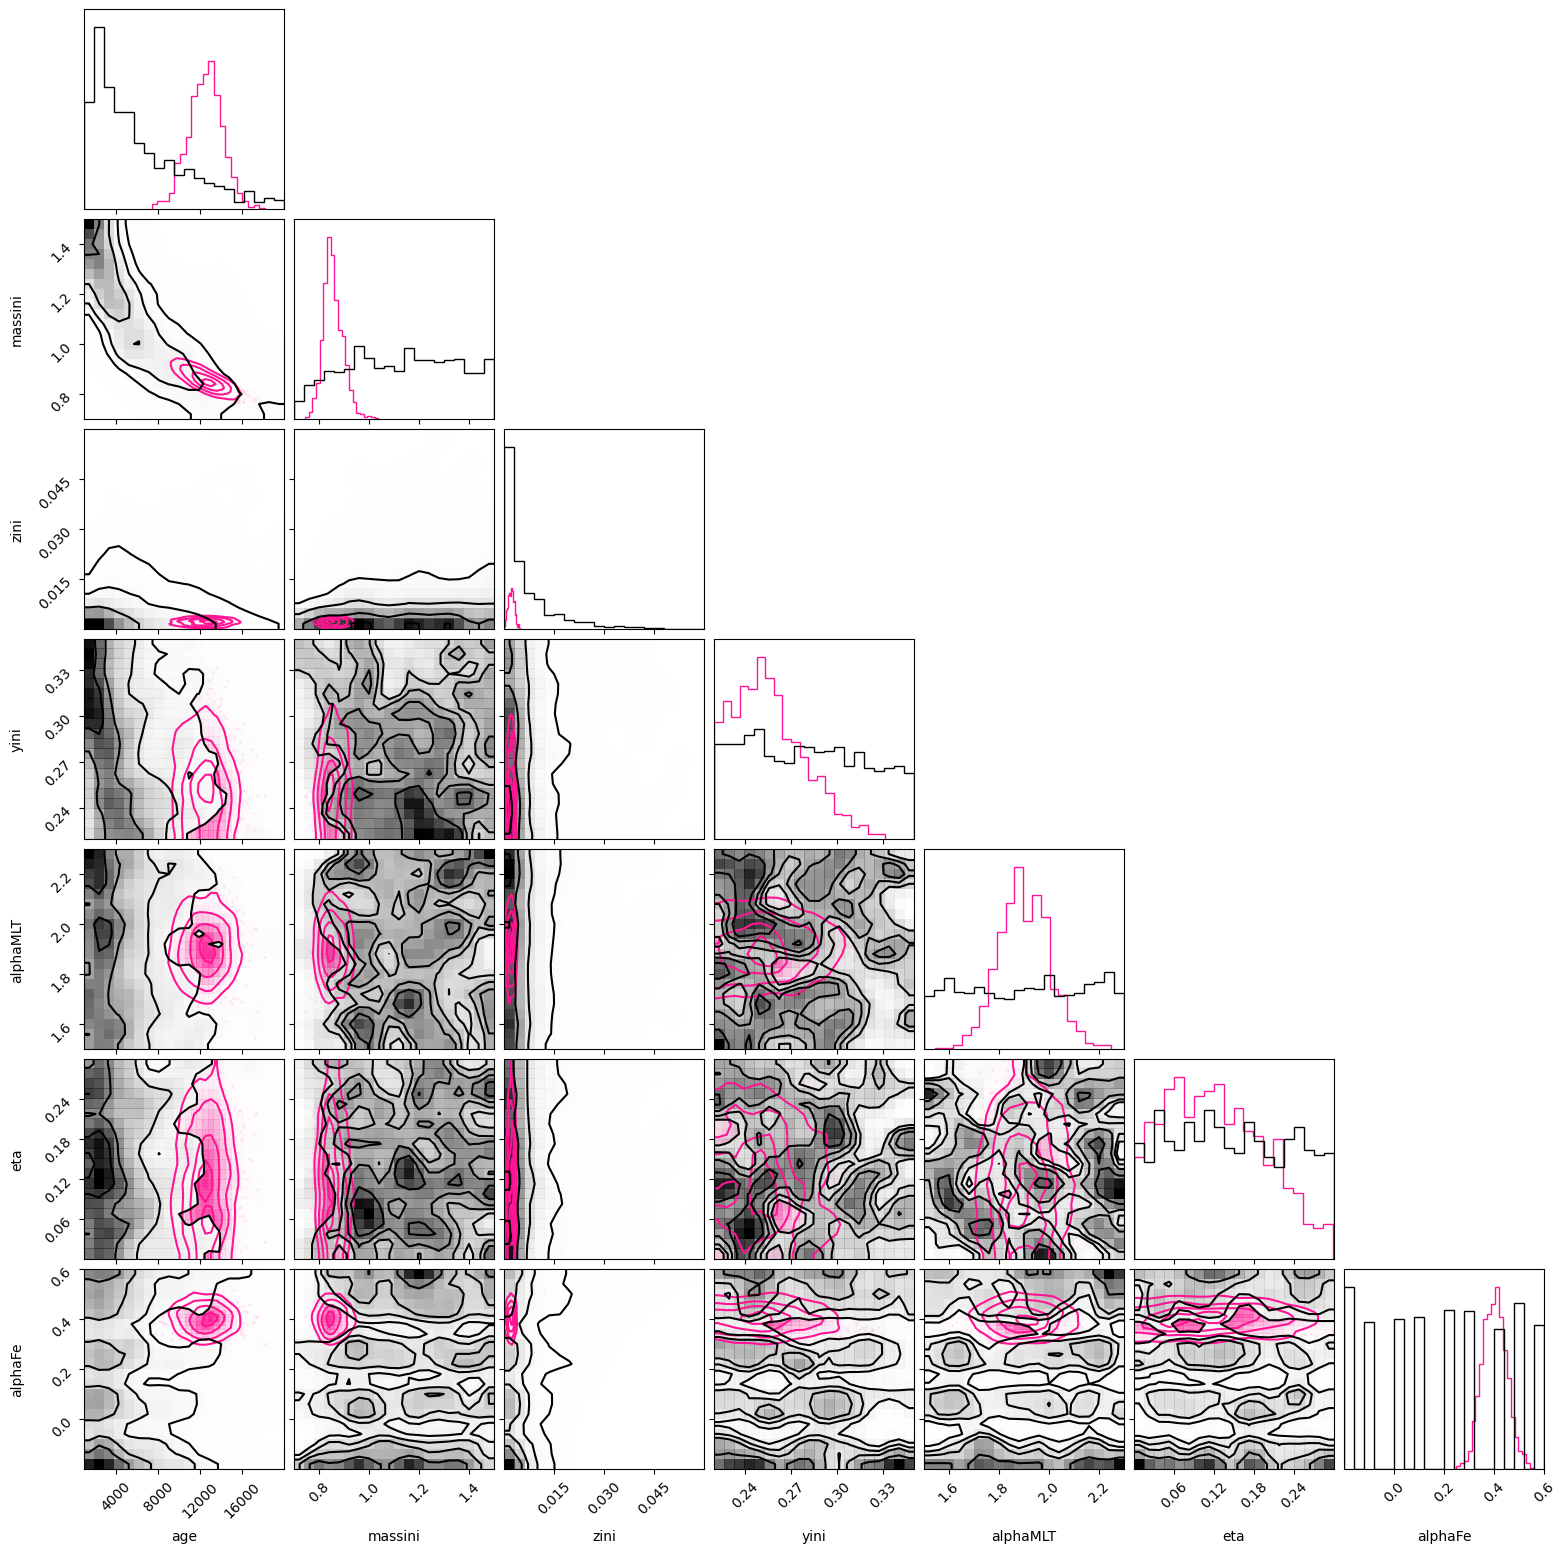

In [248]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini','zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', smooth = True, plot_datapoints = True,  weights = np.ones(num_prior_samples)/(num_prior_samples), zorder = 100, coords = {'star':0})
corner.corner(df_small[['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']],zorder = 0, alpha = 0.1, fig = fig, smooth = True, weights = np.ones_like(df_small['massini'])/len(df_small), plot_datapoints = False,)
plt.show()

In [ ]:
mcmc.run(jax.random.PRNGKey(0),  uncs=unc, obs=obs)

mcmc.print_summary()

warmup:   7%|███████████▎                                                                                                                                                         | 549/8000 [02:01<40:11,  3.09it/s, 1023 steps of size 7.71e-04. acc. prob=0.83]

In [228]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(shared_2param, posterior_samples=posterior, parallel=True, batch_ndims=2)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)

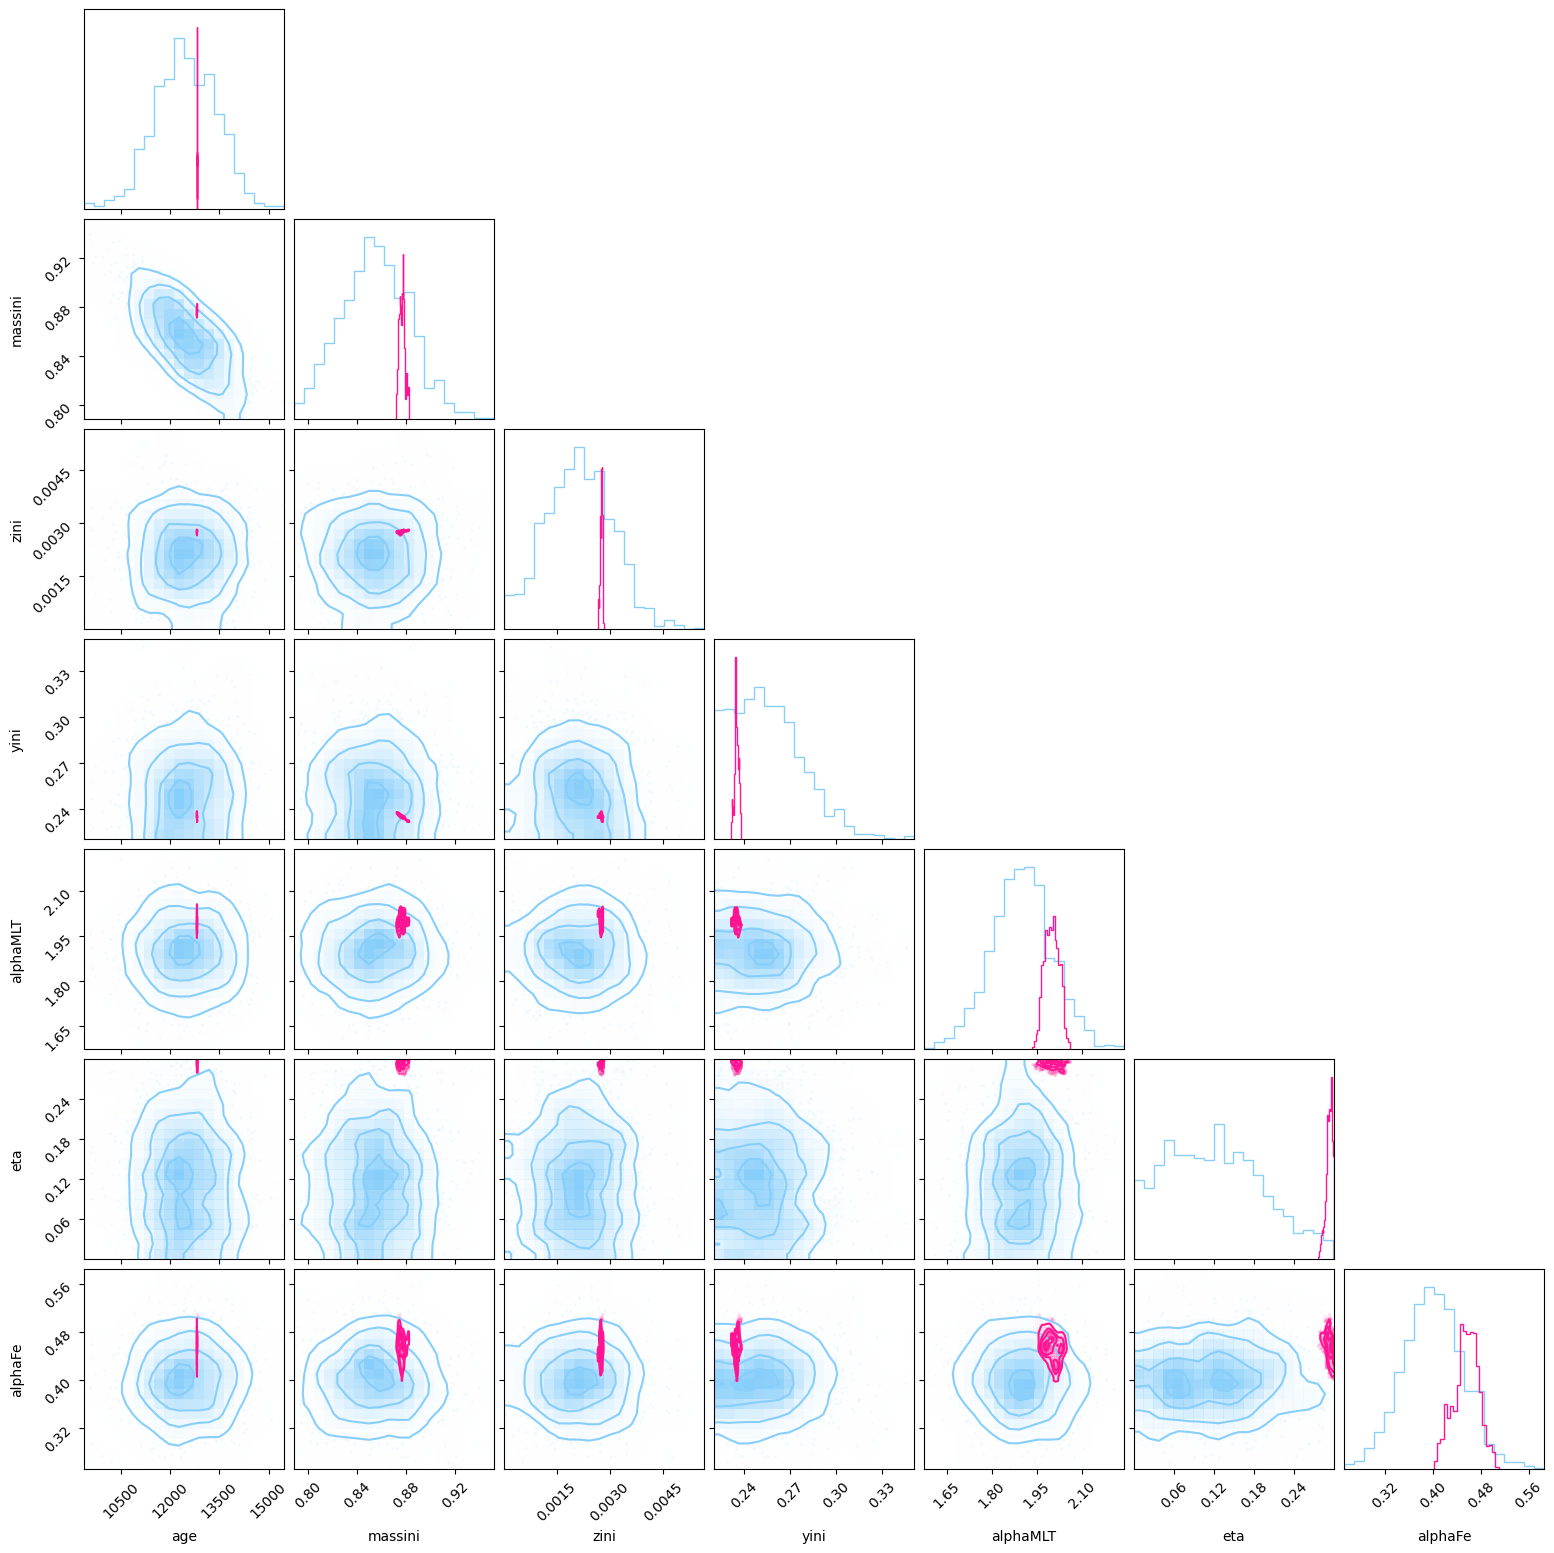

In [229]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'lightskyblue', smooth = True, plot_datapoints = True, weights = np.ones(num_prior_samples)/(num_prior_samples), coords = {'star':1})
corner.corner(data, group="posterior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True, weights = np.ones(num_chains*num_samples)/(num_chains*num_samples),fig = fig, coords = {'star':1})
#fig.savefig(f'./hierarchical-yini-zini-age-corner-massfromage.png', bbox_inches = 'tight', dpi = 150)
plt.show()


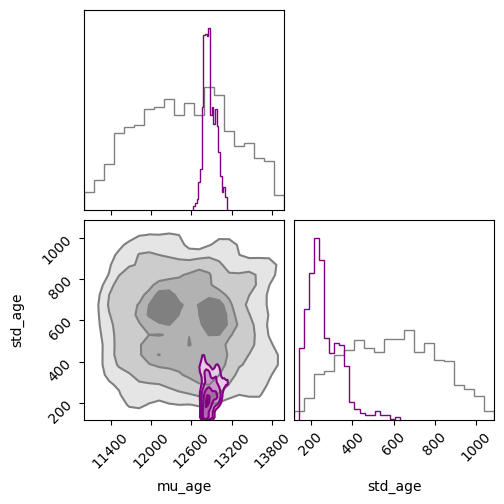

In [230]:
fig = corner.corner(data, group = 'prior', var_names = ['mu_age', 'std_age', ], color = 'grey', smooth = True, weights = np.ones(num_prior_samples)/num_prior_samples, alpha = 0.02, fill_contours = True, plot_datapoints = False)
corner.corner(data, group="posterior", var_names = ['mu_age', 'std_age', ], color = 'purple', plot_datapoints = False, smooth = True, weights = np.ones(num_chains*num_samples)/(num_chains*num_samples), fill_contours = True, fig = fig,)
plt.show()

In [27]:
np.std(obs['zini'])

np.float64(0.00016341521924013945)

In [59]:
np.mean(posterior['std_yini'].T[0])

Array(0.00137752, dtype=float64)